In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.decoding2 as decoding2
import analysis_code.statistics_test as st
from IPython.display import display, HTML
import analysis_code.place_cell as pc

def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path

#OUT = Path("figures"); OUT.mkdir(exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,    
})

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
maps = [str(i) for i in np.arange(1, 13)] + ['14', '15', '17', '19']
days1 = [str(i) for i in np.arange(0, 13)] + ['14', '15', '17', '19']
configs = [
    ('Context1', maps, '0', days1, False, False, True),  
    ('Context1', maps, '0', days1, False, False, False) 
]

def run_analysis(datapath, context, sessions, ref_session, days, cross, is_drift, use_ind_info, percentage):
    ind_info, inf_random = analysis.spatial_info_cells(datapath, ref_session, context, percentage=percentage, bins=20, remove_inactive=False, standardize='stand', remove_day_inactive=False)
    
    cell_indices = ind_info if use_ind_info else inf_random
    res_align = analysis.loop_sessions_2datas(analysis.AK_align_2_sets2, datapath, ref_session, sessions, context, cross, 'dpca', 6, False, False, False, cell_indices)
   
    translation_scale = [r[8] for r in res_align]
    ref = [r[0][r[2]] for r in res_align]
    align_population = [r[1][r[2]] for r in res_align]
    align_population.insert(0, ref[0])
   
    pop_correlation = [pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) for day in range(len(res_align))]
    rotated_data2 = [r[4] for r in res_align]
    pos_data2 = [r[5] for r in res_align]
    data1 = res_align[0][6]
    pos_data1 = res_align[0][7]
    scores_test, scores_new_list, _, _, _, _ = decoding2.decode_neural_activity(
        data1, pos_data1, rotated_data2, pos_data2,
        use_shuffled=False, shuffle_seed=0, model_type='gnb'
    )

    return {
        'ref': ref,
        'align_population': align_population,
        'days': days,
        'pop_correlation': pop_correlation,
        'translation_scale': translation_scale,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,

    }

percentage =90
results = {}
for i, (context, sessions, ref_session, days, cross, is_drift, use_ind_info) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift, use_ind_info, percentage
        )

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.6049,0.2575,0.2530,0.2010,0.1922,0.1669,0.2931,0.2030,0.1839,0.1747,0.2096,0.5227,0.2035,0.2919,0.2796,0.2080,0.7000
51004,0.4620,0.2576,0.2522,0.2113,0.2142,0.2690,0.2729,0.6205,0.7429,1.2703,0.9648,0.3551,1.3046,1.4830,1.1859,0.8033,1.6652
51007,0.3685,0.1438,0.1536,0.1833,0.2105,0.1871,0.1963,0.1795,0.1730,0.1730,0.1864,0.1854,0.2054,0.2033,0.3065,0.1885,0.3111
63,0.5717,0.1538,0.2965,0.3232,1.2858,1.4385,0.9240,0.4628,0.5277,0.8003,1.1643,1.2580,1.0745,0.9204,1.0163,0.9127,0.7011
64,0.1315,0.1534,0.1610,0.1029,0.1002,0.1075,0.1116,0.1083,0.1143,0.1188,0.1356,0.1135,0.1151,0.1070,0.1035,0.1301,0.1013
65,0.2839,0.2260,0.1628,0.1715,0.1690,0.2869,0.2591,0.2833,0.2578,0.2182,0.5250,0.3734,0.4024,0.5202,0.6946,0.3323,0.3241


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.4062,0.2373,0.2119,0.1779,0.1845,0.1501,0.2530,0.1784,0.1875,0.1848,0.1965,0.2077,0.1830,0.2566,0.2809,0.1825,0.3416
51004,0.3858,0.2377,0.2401,0.1908,0.2072,0.2016,0.2546,0.3531,0.6204,0.3379,0.7708,0.2640,0.2959,1.2122,0.9830,0.5876,0.2405
51007,0.2732,0.1382,0.1475,0.1758,0.1944,0.1827,0.1864,0.1584,0.1752,0.1599,0.1938,0.2148,0.4235,0.2108,0.1758,0.1692,0.1736
63,0.4177,0.1508,0.1603,0.2221,0.6449,0.8550,0.2053,0.2650,0.4900,0.3542,1.1585,1.1109,0.6617,0.6499,0.6079,0.8837,0.3461
64,0.1061,0.1563,0.1454,0.1119,0.1079,0.1097,0.1092,0.1225,0.1209,0.1396,0.1440,0.1367,0.1357,0.1241,0.1163,0.1436,0.1100
65,0.2017,0.2131,0.1504,0.1788,0.1704,0.2583,0.2371,0.2264,0.2437,0.3103,0.3170,0.2578,0.2718,0.2281,0.3501,0.3441,0.1867


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,2.256378,16,80,0.141024,1.867326,0.036139,0.198230,0.118699,0.139681
1,condition,0.723212,1,5,0.723212,4.985582,0.075894,0.075894,0.041383,1.000000
2,time * condition,0.446336,16,80,0.027896,1.376988,0.174716,0.296655,0.025951,0.121110


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,remove 10 percent stable,remove 10 percent random,t-test,4.1860,0.0086,0.1463,,1.7089,Cohen's d,0.4037,0.2985,0.1053,0.0616,6,True,0.7641
1,d1,remove 10 percent stable,remove 10 percent random,t-test,2.5371,0.0521,0.8854,,1.0357,Cohen's d,0.1987,0.1889,0.0098,0.0094,6,True,0.5086
2,d2,remove 10 percent stable,remove 10 percent random,wilcoxon,0.0000,0.0312,0.5312,,0.8987,r,0.2132,0.1759,0.0373,0.0500,6,False,0.0037
3,d3,remove 10 percent stable,remove 10 percent random,wilcoxon,4.0000,0.2188,1.0000,,0.5563,r,0.1989,0.1762,0.0227,0.0407,6,False,0.0397
4,d4,remove 10 percent stable,remove 10 percent random,wilcoxon,5.0000,0.3125,1.0000,,0.4708,r,0.3620,0.2516,0.1104,0.2600,6,False,0.0001
5,d5,remove 10 percent stable,remove 10 percent random,wilcoxon,1.0000,0.0625,1.0000,,0.8131,r,0.4093,0.2929,0.1164,0.2301,6,False,0.0003
6,d6,remove 10 percent stable,remove 10 percent random,wilcoxon,0.0000,0.0312,0.5312,,0.8987,r,0.3428,0.2076,0.1352,0.2861,6,False,0.0001
7,d7,remove 10 percent stable,remove 10 percent random,t-test,1.9965,0.1024,1.0000,,0.8151,Cohen's d,0.3096,0.2173,0.0923,0.1132,6,True,0.1620
8,d8,remove 10 percent stable,remove 10 percent random,wilcoxon,6.0000,0.4375,1.0000,,0.3852,r,0.3333,0.3063,0.0270,0.0496,6,False,0.0195
9,d9,remove 10 percent stable,remove 10 percent random,wilcoxon,8.0000,0.6875,1.0000,,0.2140,r,0.4592,0.2478,0.2114,0.4023,6,False,0.0344


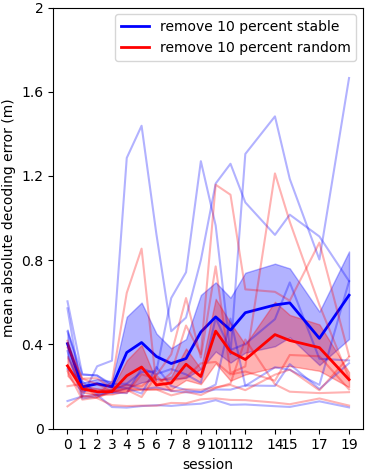

In [3]:
animals = list(results['config_1'].keys())
num_animals = len(animals)
num_days = len(results['config_1'][animals[0]]['scores_new_list']) + 1

mae_array = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array[0, i] = results['config_1'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array[day, i] = results['config_1'][animal]['scores_new_list'][day-1]['mae']

mae_array_random = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array_random[0, i] = results['config_2'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array_random[day, i] = results['config_2'][animal]['scores_new_list'][day-1]['mae']

mae_array = mae_array / 5
mae_array_random = mae_array_random / 5

fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry(
    [mae_array.T,
        mae_array_random.T],
    days,
    ax=ax,
    colors=['b', 'r'],
    ylim=[0, 2],
    ylabel='mean absolute decoding error (m)',
    labels=['remove 10 percent stable', 'remove 10 percent random']
)
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
stat1 = st.repeated_measures_anova_general(
    [mae_array.T, mae_array_random.T],
    row_labels=animals, col_labels=st.day_labels(days),
    condition_labels=['remove 10 percent stable', 'remove 10 percent random'],
    title='Decoder MAE (m) after removing 10% of cells: most stable vs random')
display(stat1[0])
display(stat1[1])

In [4]:
percentage =70
results = {}
for i, (context, sessions, ref_session, days, cross, is_drift, use_ind_info) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift, use_ind_info, percentage
        )

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.6049,0.2575,0.2530,0.2010,0.1922,0.1669,0.2931,0.2030,0.1839,0.1747,0.2096,0.5227,0.2035,0.2924,0.2796,0.2080,0.7001
51004,0.4620,0.2576,0.2522,0.2113,0.2142,0.2691,0.2729,0.6212,0.7429,1.2703,0.9650,0.3551,1.3046,1.4830,1.1859,0.8033,1.6652
51007,0.3685,0.1440,0.1536,0.1833,0.2105,0.1871,0.1962,0.1795,0.1730,0.1730,0.1864,0.1854,0.2054,0.2033,0.3065,0.1885,0.3111
63,0.5717,0.1538,0.2965,0.3232,1.2858,1.4387,0.9240,0.4628,0.5277,0.8003,1.1642,1.2580,1.0745,0.9204,1.0163,0.9127,0.7011
64,0.1315,0.1534,0.1610,0.1029,0.1002,0.1075,0.1116,0.1083,0.1143,0.1188,0.1356,0.1135,0.1151,0.1070,0.1035,0.1301,0.1013
65,0.2839,0.2260,0.1628,0.1715,0.1690,0.2872,0.2591,0.2833,0.2578,0.2182,0.5250,0.3735,0.4024,0.5202,0.6946,0.3323,0.3241


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3601,0.2810,0.2654,0.2162,0.1952,0.1844,0.2962,0.1975,0.1705,0.1933,0.2096,0.2182,0.1881,0.2523,0.3154,0.2199,0.4129
51004,0.3859,0.2427,0.2501,0.1822,0.2045,0.1824,0.2212,0.3709,0.7752,0.4527,0.8464,0.5122,0.9360,1.1299,0.9410,0.7688,1.4499
51007,0.3138,0.1512,0.1650,0.1923,0.2040,0.2044,0.2069,0.1836,0.2136,0.1902,0.2053,0.2373,0.2784,0.2164,0.1981,0.1747,0.1946
63,0.3861,0.1717,0.1666,0.2532,1.5910,1.4054,0.5147,0.3476,0.4557,0.4112,0.8063,0.7730,0.2001,0.8145,0.4336,0.5413,0.1436
64,0.1120,0.1456,0.1523,0.1114,0.1099,0.1127,0.1175,0.1300,0.1219,0.1441,0.1501,0.1374,0.1260,0.1231,0.1159,0.1300,0.1084
65,0.1966,0.2331,0.1645,0.1807,0.1823,0.2761,0.2591,0.2283,0.2316,0.2834,0.2708,0.2739,0.3367,0.4937,0.2357,0.3157,0.1727


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,2.284630,16,80,0.142789,1.290270,0.224130,0.317320,0.103252,0.123952
1,condition,0.372593,1,5,0.372593,4.236977,0.094627,0.094627,0.018432,1.000000
2,time * condition,0.338571,16,80,0.021161,1.798437,0.045674,0.200796,0.016777,0.161086


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,remove 30 percent stable,remove 30 percent random,t-test,3.1786,0.0246,0.4178,,1.2977,Cohen's d,0.4037,0.2924,0.1113,0.0858,6,True,0.4115
1,d1,remove 30 percent stable,remove 30 percent random,t-test,-0.9155,0.4019,1.0000,,-0.3737,Cohen's d,0.1987,0.2042,-0.0055,0.0147,6,True,0.7081
2,d2,remove 30 percent stable,remove 30 percent random,wilcoxon,10.0000,1.0000,1.0000,,0.0428,r,0.2132,0.1940,0.0192,0.0548,6,False,0.0011
3,d3,remove 30 percent stable,remove 30 percent random,wilcoxon,10.0000,1.0000,1.0000,,0.0428,r,0.1989,0.1893,0.0096,0.0337,6,False,0.0244
4,d4,remove 30 percent stable,remove 30 percent random,wilcoxon,5.0000,0.3125,1.0000,,0.4708,r,0.3620,0.4145,-0.0525,0.1241,6,False,0.0002
5,d5,remove 30 percent stable,remove 30 percent random,t-test,0.9292,0.3954,1.0000,,0.3793,Cohen's d,0.4094,0.3942,0.0152,0.0400,6,True,0.1679
6,d6,remove 30 percent stable,remove 30 percent random,wilcoxon,9.0000,0.8438,1.0000,,0.1284,r,0.3428,0.2693,0.0736,0.1661,6,False,0.0004
7,d7,remove 30 percent stable,remove 30 percent random,t-test,1.5904,0.1726,1.0000,,0.6493,Cohen's d,0.3097,0.2430,0.0667,0.1027,6,True,0.1815
8,d8,remove 30 percent stable,remove 30 percent random,t-test,0.3039,0.7735,1.0000,,0.1241,Cohen's d,0.3333,0.3281,0.0052,0.0416,6,True,0.7542
9,d9,remove 30 percent stable,remove 30 percent random,wilcoxon,10.0000,1.0000,1.0000,,0.0428,r,0.4592,0.2792,0.1800,0.3552,6,False,0.0165


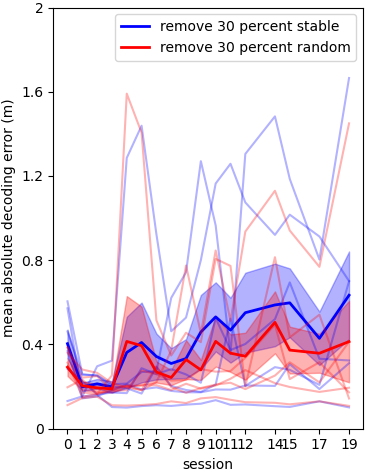

In [5]:
animals = list(results['config_1'].keys())
num_animals = len(animals)
num_days = len(results['config_1'][animals[0]]['scores_new_list']) + 1

mae_array = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array[0, i] = results['config_1'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array[day, i] = results['config_1'][animal]['scores_new_list'][day-1]['mae']

mae_array_random = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array_random[0, i] = results['config_2'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array_random[day, i] = results['config_2'][animal]['scores_new_list'][day-1]['mae']

mae_array = mae_array / 5
mae_array_random = mae_array_random / 5

fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry(
    [mae_array.T,
        mae_array_random.T],
    days,
    ax=ax,
    colors=['b', 'r'],
    ylim=[0, 2],
    ylabel='mean absolute decoding error (m)',
    labels=['remove 30 percent stable', 'remove 30 percent random']
)
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
stat1 = st.repeated_measures_anova_general(
    [mae_array.T, mae_array_random.T],
    row_labels=animals, col_labels=st.day_labels(days),
    condition_labels=['remove 30 percent stable', 'remove 30 percent random'],
    title='Decoder MAE (m) after removing 30% of cells: most stable vs random')
display(stat1[0])
display(stat1[1])

In [6]:
percentage =50
results = {}
for i, (context, sessions, ref_session, days, cross, is_drift, use_ind_info) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift, use_ind_info, percentage
        )

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.6049,0.2575,0.2530,0.2010,0.1922,0.1669,0.2931,0.2031,0.1839,0.1747,0.2096,0.5227,0.2035,0.2918,0.2796,0.2080,0.7002
51004,0.4620,0.2576,0.2522,0.2113,0.2142,0.2690,0.2729,0.6205,0.7429,1.2703,0.9650,0.3551,1.3048,1.4830,1.1859,0.8033,1.6652
51007,0.3685,0.1440,0.1536,0.1833,0.2105,0.1871,0.1963,0.1795,0.1730,0.1730,0.1864,0.1854,0.2054,0.2033,0.3066,0.1885,0.3111
63,0.5717,0.1538,0.2965,0.3232,1.2860,1.4381,0.9240,0.4628,0.5277,0.8003,1.1643,1.2580,1.0745,0.9204,1.0163,0.9126,0.7011
64,0.1315,0.1534,0.1610,0.1029,0.1002,0.1075,0.1116,0.1083,0.1143,0.1188,0.1356,0.1135,0.1151,0.1070,0.1035,0.1301,0.1013
65,0.2839,0.2260,0.1628,0.1715,0.1690,0.2869,0.2591,0.2833,0.2578,0.2182,0.5250,0.3734,0.4025,0.5202,0.6946,0.3323,0.3241


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3564,0.3306,0.3238,0.2458,0.2951,0.2069,0.3219,0.2166,0.2303,0.2257,0.3014,0.4137,0.2337,0.2944,0.4658,0.2270,0.5911
51004,0.4135,0.2589,0.2884,0.2260,0.2698,0.2667,0.3939,0.3629,0.3814,0.5768,0.7919,0.5751,1.0406,0.9865,1.0443,0.8759,0.9609
51007,0.3298,0.1879,0.1866,0.1892,0.1944,0.1839,0.1963,0.1875,0.2038,0.1698,0.2559,0.2567,0.2509,0.2189,0.2473,0.2193,0.2178
63,0.4941,0.2721,0.2138,0.3319,0.3668,0.7214,0.4529,0.4758,0.5750,0.6226,0.9257,1.2766,0.7838,1.0085,1.2440,0.9566,1.0300
64,0.1375,0.1782,0.1540,0.1240,0.1218,0.1240,0.1238,0.1389,0.1307,0.1475,0.1486,0.1484,0.1414,0.1345,0.1297,0.1461,0.1263
65,0.2053,0.2294,0.1837,0.1916,0.1795,0.2970,0.2962,0.2491,0.4569,0.4957,0.5080,0.2022,0.6341,0.2538,0.2962,0.8633,0.3324


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,3.223846,16,80,0.201490,2.674849,0.002016,0.110809,0.148334,0.135886
1,condition,0.060159,1,5,0.060159,1.071056,0.348142,0.348142,0.003240,1.000000
2,time * condition,0.193734,16,80,0.012108,0.566341,0.899858,0.604510,0.010358,0.142784


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,remove 50 percent stable,remove 50 percent random,t-test,2.2602,0.0733,1.0000,,0.9227,Cohen's d,0.4037,0.3228,0.0810,0.0878,6,True,0.0841
1,d1,remove 50 percent stable,remove 50 percent random,t-test,-2.3918,0.0623,1.0000,,-0.9764,Cohen's d,0.1987,0.2428,-0.0441,0.0452,6,True,0.4477
2,d2,remove 50 percent stable,remove 50 percent random,t-test,-0.5508,0.6055,1.0000,,-0.2249,Cohen's d,0.2132,0.2250,-0.0119,0.0527,6,True,0.3817
3,d3,remove 50 percent stable,remove 50 percent random,t-test,-3.3667,0.0200,0.3394,,-1.3744,Cohen's d,0.1989,0.2181,-0.0192,0.0140,6,True,0.2192
4,d4,remove 50 percent stable,remove 50 percent random,wilcoxon,8.0000,0.6875,1.0000,,0.2140,r,0.3620,0.2379,0.1241,0.3917,6,False,0.0005
5,d5,remove 50 percent stable,remove 50 percent random,wilcoxon,9.0000,0.8438,1.0000,,0.1284,r,0.4093,0.3000,0.1093,0.2980,6,False,0.0001
6,d6,remove 50 percent stable,remove 50 percent random,wilcoxon,5.0000,0.5002,1.0000,,0.4708,r,0.3428,0.2975,0.0453,0.2129,6,False,0.0038
7,d7,remove 50 percent stable,remove 50 percent random,wilcoxon,10.0000,1.0000,1.0000,,0.0428,r,0.3096,0.2718,0.0378,0.1098,6,False,0.0021
8,d8,remove 50 percent stable,remove 50 percent random,wilcoxon,6.0000,0.4375,1.0000,,0.3852,r,0.3333,0.3297,0.0036,0.1875,6,False,0.0391
9,d9,remove 50 percent stable,remove 50 percent random,t-test,0.6376,0.5518,1.0000,,0.2603,Cohen's d,0.4592,0.3730,0.0862,0.3312,6,True,0.2324


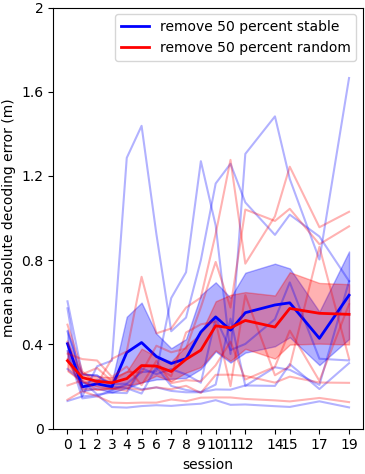

In [7]:
animals = list(results['config_1'].keys())
num_animals = len(animals)
num_days = len(results['config_1'][animals[0]]['scores_new_list']) + 1

mae_array = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array[0, i] = results['config_1'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array[day, i] = results['config_1'][animal]['scores_new_list'][day-1]['mae']

mae_array_random = np.zeros((num_days, num_animals))
for i, animal in enumerate(animals):
    mae_array_random[0, i] = results['config_2'][animal]['scores_test']['mae']
    for day in range(1, num_days):
        mae_array_random[day, i] = results['config_2'][animal]['scores_new_list'][day-1]['mae']

mae_array = mae_array / 5
mae_array_random = mae_array_random / 5

fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry(
    [mae_array.T,
        mae_array_random.T],
    days,
    ax=ax,
    colors=['b', 'r'],
    ylim=[0, 2],
    ylabel='mean absolute decoding error (m)',
    labels=['remove 50 percent stable', 'remove 50 percent random']
)
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
stat1 = st.repeated_measures_anova_general(
    [mae_array.T, mae_array_random.T],
    row_labels=animals, col_labels=st.day_labels(days),
    condition_labels=['remove 50 percent stable', 'remove 50 percent random'],
    title='Decoder MAE (m) after removing 50% of cells: most stable vs random')
display(stat1[0])
display(stat1[1])

In [8]:
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
days1 = [str(i) for i in np.arange(0, 13)] +  ['14', '15', '17', '19']
days2 = ['19','17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]

configs = [
    ('Context1', maps, '0', days1, False, False),  
    ('Context1', None, '0', days1, False, True)
     
]

def run_analysis(datapath, context, sessions, ref_session, days, cross, is_drift):
    if not is_drift:
        res_align = analysis.loop_sessions_2datas(analysis.AK_align_2_sets2, datapath, ref_session, sessions, context, cross, 'pca', 6)
    else:
        simu_drift = analysis.simulate_drift(
            datapath, 
            session=ref_session, 
            Context=context, 
            days=len(days),  
            drift_type='circular', 
            standardize='stand', 
            odd_even=True, 
            global_seed=0, 
            remove_day_inactive=True
        )
        res_align = analysis.loop_sessions_3(
            analysis.AK_align_2_sets_sim, 
            simu_drift['drift_data'][0], 
            simu_drift['drift_data'][1:], 
            simu_drift['pos'],
            'pca',
            6
        )
    
    translation_scale = [r[8] for r in res_align]
    ref = [r[0][r[2]] for r in res_align]
    align_population = [r[1][r[2]] for r in res_align]
    align_population.insert(0, ref[0])
    
    pop_correlation = [pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) for day in range(len(res_align))]
    error = [[r[3][6], r[3][5]] for r in res_align]
    rotated_data2 = [r[4] for r in res_align]
    pos_data2 = [r[5] for r in res_align]
    data1 = res_align[0][6]
    pos_data1 = res_align[0][7]
    scores_test, scores_new_list, _, _, _, _ = decoding2.decode_neural_activity(
        data1, pos_data1, rotated_data2, pos_data2, 
        use_shuffled=False, shuffle_seed=0, model_type='gnb'
    )
    scores_test_shuff, scores_new_list_shuff, _, _, _, _ = decoding2.decode_neural_activity(
        data1, pos_data1, rotated_data2, pos_data2, 
        use_shuffled=True, shuffle_seed=0, model_type='gnb'
    )
     
    return {
        'ref': ref,
        'align_population': align_population,
        'days': days,
        'pop_correlation': pop_correlation,
        'translation_scale': translation_scale,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'scores_test_shuff': scores_test_shuff,
        'scores_new_list_shuff': scores_new_list_shuff,
        'errors': error
    }

results = {}
for i, (context, sessions, ref_session, days, cross, is_drift) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift
        )

C:\Users\oles\AppData\Local\Temp\ipykernel_29188\1714601156.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


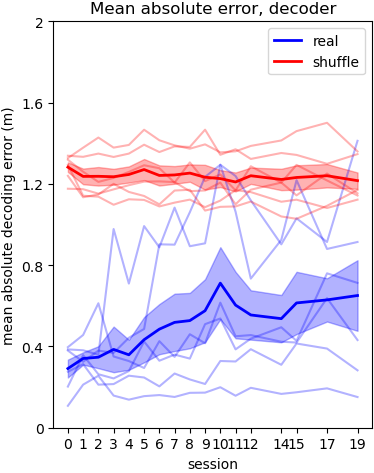

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3965,0.4564,0.6125,0.3506,0.3281,0.2940,0.4260,0.3487,0.4601,0.4157,0.6154,0.4500,0.4560,0.4232,0.4193,0.6375,0.4315
51004,0.3797,0.3246,0.3795,0.3683,0.4427,0.4860,0.9026,0.9010,1.0604,1.2346,1.2940,1.2386,1.1187,0.9025,1.0305,0.9141,1.4120
51007,0.2754,0.3131,0.2119,0.2148,0.2561,0.2471,0.2035,0.2668,0.2376,0.2153,0.3284,0.3260,0.3864,0.3097,0.4145,0.3895,0.2824
63,0.3854,0.3812,0.3592,0.9779,0.7094,0.9923,0.8879,1.0832,0.8932,0.9075,1.2945,1.0631,0.7339,0.9243,1.2185,0.8798,0.9141
64,0.1078,0.2120,0.2557,0.1582,0.1381,0.1554,0.1607,0.1514,0.1717,0.1727,0.1993,0.1575,0.1964,0.1664,0.1745,0.1938,0.1510
65,0.2025,0.3570,0.2633,0.2426,0.2789,0.4243,0.3298,0.3599,0.3402,0.5097,0.5376,0.3856,0.4382,0.4944,0.4276,0.7598,0.7127


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.1762,1.1739,1.1519,1.1730,1.1935,1.2112,1.2124,1.2087,1.1641,1.1677,1.2064,1.0997,1.1714,1.2066,1.1434,1.2508,1.1536
51004,1.2931,1.1417,1.1371,1.0973,1.1242,1.1211,1.0891,1.1078,1.1227,1.0854,1.1179,1.1692,1.1596,1.1121,1.1223,1.0814,1.1225
51007,1.2396,1.1342,1.1481,1.2002,1.1604,1.1405,1.0994,1.1673,1.1711,1.0686,1.0870,1.0891,1.1131,1.0397,1.0282,1.0920,1.1702
63,1.3189,1.2598,1.2098,1.2295,1.2590,1.2917,1.2770,1.2063,1.3058,1.2136,1.2465,1.1680,1.2868,1.2063,1.2934,1.2168,1.1429
64,1.3386,1.3332,1.3491,1.3325,1.3490,1.3928,1.3567,1.3845,1.3819,1.4668,1.3432,1.3704,1.3228,1.3520,1.3426,1.2988,1.3466
65,1.3269,1.3781,1.4281,1.3785,1.3917,1.4665,1.4147,1.3896,1.3732,1.3945,1.3552,1.3603,1.3869,1.4137,1.4597,1.5007,1.3598


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.631728,16,80,0.039483,2.293548,0.008052,0.139209,0.054937,0.147154
1,condition,27.579160,1,5,27.579160,26.946308,0.003493,0.003493,0.717336,1.000000
2,time * condition,0.892406,16,80,0.055775,3.347077,0.000173,0.083629,0.075886,0.114733


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-15.0541,2.3427e-05,0.0004,***,-6.1458,Cohen's d,0.2912,1.2822,-0.9910,0.1612,6,True,0.7650
1,d1,real,shuffle,t-test,-14.7720,2.5705e-05,0.0004,***,-6.0307,Cohen's d,0.3407,1.2368,-0.8961,0.1486,6,True,0.6508
2,d2,real,shuffle,t-test,-9.5452,0.0002,0.0036,**,-3.8968,Cohen's d,0.3470,1.2374,-0.8903,0.2285,6,True,0.9113
3,d3,real,shuffle,t-test,-6.1182,0.0017,0.0288,*,-2.4978,Cohen's d,0.3854,1.2352,-0.8498,0.3402,6,True,0.3766
4,d4,real,shuffle,t-test,-8.6918,0.0003,0.0057,**,-3.5484,Cohen's d,0.3589,1.2463,-0.8874,0.2501,6,True,0.8665
5,d5,real,shuffle,t-test,-6.2313,0.0016,0.0265,*,-2.5439,Cohen's d,0.4332,1.2706,-0.8375,0.3292,6,True,0.7838
6,d6,real,shuffle,t-test,-4.6878,0.0054,0.0917,,-1.9138,Cohen's d,0.4851,1.2415,-0.7565,0.3953,6,True,0.6091
7,d7,real,shuffle,t-test,-3.9142,0.0112,0.1912,,-1.5980,Cohen's d,0.5185,1.2440,-0.7256,0.4541,6,True,0.2355
8,d8,real,shuffle,t-test,-4.1654,0.0088,0.1492,,-1.7005,Cohen's d,0.5272,1.2531,-0.7259,0.4269,6,True,0.7763
9,d9,real,shuffle,t-test,-3.1820,0.0245,0.4162,,-1.2991,Cohen's d,0.5759,1.2328,-0.6569,0.5056,6,True,0.7031


C:\Users\oles\AppData\Local\Temp\ipykernel_29188\1714601156.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


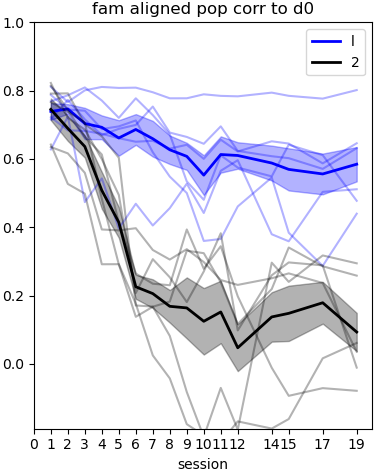

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7225,0.6837,0.6821,0.6735,0.6606,0.6504,0.6532,0.6303,0.6414,0.6003,0.6563,0.6219,0.6517,0.6450,0.5870,0.6459
51004,0.7876,0.7447,0.7411,0.6875,0.6953,0.7127,0.6196,0.5483,0.5002,0.3598,0.3656,0.4609,0.5456,0.3840,0.2868,0.4396
51007,0.7165,0.7728,0.7159,0.6699,0.6881,0.6996,0.7534,0.6771,0.6644,0.6443,0.6954,0.6235,0.6079,0.6022,0.5709,0.6315
63,0.6277,0.7240,0.4736,0.5428,0.3962,0.4688,0.4051,0.4560,0.5275,0.4417,0.5653,0.5963,0.3795,0.3588,0.5036,0.5112
64,0.8112,0.7666,0.8008,0.8108,0.8079,0.8088,0.7953,0.7775,0.7776,0.7892,0.7847,0.7833,0.7942,0.7848,0.7766,0.8016
65,0.7686,0.7865,0.8094,0.7710,0.7202,0.7775,0.7283,0.6718,0.5342,0.4803,0.6104,0.5747,0.5490,0.6416,0.6111,0.4774


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.6349,0.6162,0.5593,0.3934,0.3908,0.3971,0.3334,0.3054,0.3357,0.2980,0.2454,0.2311,0.2505,0.2649,0.2368,0.0354
51004,0.8224,0.7202,0.6859,0.5994,0.4945,0.2075,0.3065,0.2535,0.1809,0.2704,0.3824,0.0979,0.2593,0.2970,0.2883,-0.0110
51007,0.7662,0.7381,0.7070,0.4834,0.2911,0.1377,0.1672,0.1824,0.3314,0.3240,0.2390,0.1165,0.2190,0.3406,0.2857,0.2582
63,0.6422,0.5268,0.4984,0.2916,0.2918,0.1759,0.0247,-0.0426,-0.1767,-0.2094,-0.2294,-0.1685,-0.1895,-0.1616,0.0161,0.0611
64,0.7913,0.7921,0.7016,0.6662,0.6035,0.1710,0.1677,0.0818,-0.0824,-0.2139,-0.0705,-0.1926,0.2963,0.2400,0.3174,0.2943
65,0.8139,0.7434,0.6653,0.6128,0.4139,0.2644,0.2346,0.2302,0.3935,0.2784,0.3443,0.1977,-0.0115,-0.0937,-0.0712,-0.0790


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,3.683336,15,75,0.245556,22.153001,1.290397e-21,0.000008,0.511278,0.203699
1,condition,5.795165,1,5,5.795165,63.103515,5.094726e-04,0.000509,0.622066,1.000000
2,time * condition,1.420727,15,75,0.094715,7.218272,1.740917e-09,0.006759,0.287505,0.160625


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,real (fam aligned),sim drift (aligned),t-test,-0.2873,0.7854,1.0000,,-0.1173,Cohen's d,0.7390,0.7452,-0.0062,0.0525,6,True,0.1620
1,d2,real (fam aligned),sim drift (aligned),t-test,1.8533,0.1230,1.0000,,0.7566,Cohen's d,0.7464,0.6894,0.0569,0.0752,6,True,0.1863
2,d3,real (fam aligned),sim drift (aligned),t-test,2.4941,0.0549,0.8782,,1.0182,Cohen's d,0.7038,0.6362,0.0676,0.0664,6,True,0.7169
3,d4,real (fam aligned),sim drift (aligned),t-test,6.3777,0.0014,0.0224,*,2.6037,Cohen's d,0.6926,0.5078,0.1848,0.0710,6,True,0.8591
4,d5,real (fam aligned),sim drift (aligned),t-test,6.0061,0.0018,0.0294,*,2.4520,Cohen's d,0.6614,0.4143,0.2471,0.1008,6,True,0.9660
5,d6,real (fam aligned),sim drift (aligned),t-test,7.3602,0.0007,0.0116,*,3.0048,Cohen's d,0.6863,0.2256,0.4607,0.1533,6,True,0.3197
6,d7,real (fam aligned),sim drift (aligned),t-test,8.1680,0.0004,0.0072,**,3.3346,Cohen's d,0.6591,0.2057,0.4535,0.1360,6,True,0.3213
7,d8,real (fam aligned),sim drift (aligned),t-test,7.7804,0.0006,0.0090,**,3.1763,Cohen's d,0.6268,0.1684,0.4584,0.1443,6,True,0.5813
8,d9,real (fam aligned),sim drift (aligned),t-test,3.9447,0.0109,0.1745,,1.6104,Cohen's d,0.6075,0.1637,0.4438,0.2756,6,True,0.2359
9,d10,real (fam aligned),sim drift (aligned),t-test,3.0950,0.0270,0.4321,,1.2635,Cohen's d,0.5526,0.1246,0.4280,0.3388,6,True,0.3263


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7225,0.6837,0.6821,0.6735,0.6606,0.6504,0.6532,0.6303,0.6414,0.6003,0.6563,0.6219,0.6517,0.6450,0.5870,0.6459
51004,0.7876,0.7447,0.7411,0.6875,0.6953,0.7127,0.6196,0.5483,0.5002,0.3598,0.3656,0.4609,0.5456,0.3840,0.2868,0.4396
51007,0.7165,0.7728,0.7159,0.6699,0.6881,0.6996,0.7534,0.6771,0.6644,0.6443,0.6954,0.6235,0.6079,0.6022,0.5709,0.6315
63,0.6277,0.7240,0.4736,0.5428,0.3962,0.4688,0.4051,0.4560,0.5275,0.4417,0.5653,0.5963,0.3795,0.3588,0.5036,0.5112
64,0.8112,0.7666,0.8008,0.8108,0.8079,0.8088,0.7953,0.7775,0.7776,0.7892,0.7847,0.7833,0.7942,0.7848,0.7766,0.8016
65,0.7686,0.7865,0.8094,0.7710,0.7202,0.7775,0.7283,0.6718,0.5342,0.4803,0.6104,0.5747,0.5490,0.6416,0.6111,0.4774


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.354698,15,0.023647,4.062449,0.000024,0.219362,0.146079
1,Error,0.436557,75,0.005821,NaN,NaN,NaN,NaN


In [9]:
print_large('PCA: familar')
configs = ['config_1']
def analyze_mae_config(results, config):
    animals = list(results[config].keys())
    num_animals = len(animals)
    num_days = len(results[config][animals[0]]['scores_new_list']) + 1
    
    mae_array = np.zeros((num_days, num_animals))
    mae_array_shuff = np.zeros((num_days, num_animals))
    
    for i, animal in enumerate(animals):
        mae_array[0, i] = results[config][animal]['scores_test']['mae']
        mae_array_shuff[0, i] = results[config][animal]['scores_test_shuff']['mae']
        
        for day in range(1, num_days):
            mae_array[day, i] = results[config][animal]['scores_new_list'][day-1]['mae']
            mae_array_shuff[day, i] = results[config][animal]['scores_new_list_shuff'][day-1]['mae']
    
    return mae_array / 5, mae_array_shuff / 5

def plot_mae_configs_individual(results, configs, days1, days2):
    for i, config in enumerate(configs):
        mae_array, mae_array_shuff = analyze_mae_config(results, config)
        animals = list(results[config].keys())
        print_large('\n' + '='*50)
        print_large(conf[i])
        print_large('\n' + '='*50)
        fig,ax=plt.subplots(figsize=(4, 5))
        
        days = days1 #if i != 2 else days2
        mae_array = mae_array[::-1] if i == 2 else mae_array
        mae_array_shuff = mae_array_shuff[::-1] if i == 2 else mae_array_shuff

        plots.plot_average_geometry(
            [mae_array.T,
             mae_array_shuff.T],
            days,
            ax=ax,
            colors=['b', 'r'],
            ylim=[0, 2],
            ylabel='mean absolute decoding error (m)',
            labels=['real', 'shuffle']
        )
        ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
        ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
        
        plt.title(f'Mean absolute error, decoder')
        plt.tight_layout()
        plt.show()


        stat1 = st.repeated_measures_anova_general(
            [mae_array.T, mae_array_shuff.T],
            row_labels=animals, col_labels=st.day_labels(days),
            condition_labels=['real', 'shuffle'],
            title=f'Decoder MAE (m), {conf[i]} (PCA aligned): real vs shuffle')
        display(stat1[0])
        display(stat1[1])


conf = ['fam', 'nov forward', 'nov reverse', 'across env', 'sim drift']
plot_mae_configs_individual(results, configs, days1, days2)



def create_pop_correlation_arrays(results, datapaths):
    pop_correlation_arrays = {}
    for config_name, config_results in results.items():
        pop_correlation_arrays[config_name] = np.column_stack([
            config_results[file_name]['pop_correlation']
            for file_name in [path.split('/')[-1].split('.')[0] for path in datapaths]
        ])
    return pop_correlation_arrays

def plot_pop_correlations_individual(pop_correlation_arrays, maps, maps_reverse):
    animals = st.animal_labels(datapaths)

    plot_configs = [
        {
            'config': 'config_1',
            'title': 'fam aligned pop corr to d0',
            'maps': maps
            
        },
        {
            'config': 'config_2',
            'title': 'sim fam aligned pop corr to d0',
            'maps': maps
        }

    ]

    i=0

    print_large('\n' + '='*50)
    #print_large(config[i])
    print_large('\n' + '='*50)
    fig,ax=plt.subplots(figsize=(4, 5))
    

    plots.plot_average_geometry(
        [pop_correlation_arrays['config_1'].T, pop_correlation_arrays['config_2'].T],
        plot_configs[0]['maps'],
        colors=['b', 'k'],
        ax=ax,
        title=plot_configs[0]['title'],
        ylim=[-0.19, 1],
        labels=['l', '2']
    )
    plt.tight_layout()
    plt.show()
    print_large('\nTWO-WAY REPEATED ANOVA')
    anova=st.repeated_measures_anova_general(
        [pop_correlation_arrays['config_1'].T, pop_correlation_arrays['config_2'].T],
        row_labels=animals, col_labels=st.day_labels(plot_configs[0]['maps']),
        condition_labels=['real (fam aligned)', 'sim drift (aligned)'],
        title='Pop correlation to d0 (PCA aligned): real vs simulated drift')
    display(anova[0])
    display(anova[1])
    display(st.repeated_measures_anova_single_condition(
        pop_correlation_arrays['config_1'].T,
        row_labels=animals, col_labels=st.day_labels(plot_configs[0]['maps']),
        condition_label='real (fam aligned)',
        title='Pop correlation to d0 (PCA aligned): real data'))
    i+=1
        

pop_correlation_arrays = create_pop_correlation_arrays(results, datapaths)
plot_pop_correlations_individual(pop_correlation_arrays, maps, maps_reverse)


In [10]:
maps = [str(i) for i in np.arange(1, 13)] + ['14', '15', '17', '19']
days1 = [str(i) for i in np.arange(0, 13)] + ['14', '15', '17', '19']

configs = [
    ('Context1', maps, '0', days1, False, False), 
    ('Context1', None, '0', days1, False, True)     
]

def run_analysis_simplified(datapath, context, sessions, ref_session, days, cross, is_drift, n_components):
    if not is_drift:
        res_align = analysis.loop_sessions_2datas(
            analysis.AK_align_2_sets2, datapath, ref_session, sessions, 
            context, cross, 'dpca', n_components
        )
    else:
        simu_drift = analysis.simulate_drift(
            datapath, 
            session=ref_session, 
            Context=context, 
            days=len(days),  
            drift_type='circular', 
            standardize='stand', 
            odd_even=True, 
            global_seed=0, 
            remove_day_inactive=True
        )
        res_align = analysis.loop_sessions_3(
            analysis.AK_align_2_sets_sim, 
            simu_drift['drift_data'][0], 
            simu_drift['drift_data'][1:], 
            simu_drift['pos'],
            'dpca',
            n_components
        )
    
    pop_correlation = [
        pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) 
        for day in range(len(res_align))
    ]
    
    explained_variance = res_align[0][8]['explained']  
    
    return {
        'pop_correlation': pop_correlation,
        'explained_variance': explained_variance
    }

n_components_range = range(1, 21)  # 3 to 19
results_pop_corr = {'real': {}, 'simulation': {}}
results_explained_var = {'real': {}, 'simulation': {}}

for n_components in n_components_range:
    print(f"\nProcessing {n_components} components...")
    
    for config_idx, (context, sessions, ref_session, days, cross, is_drift) in enumerate(configs):
        label = 'real' if config_idx == 0 else 'simulation'
        
        for datapath in datapaths:
            file_name = datapath.split('/')[-1].split('.')[0]
            
            result = run_analysis_simplified(
                datapath, context, sessions, ref_session, days, cross, is_drift, n_components
            )
            
            if file_name not in results_pop_corr[label]:
                results_pop_corr[label][file_name] = []
            results_pop_corr[label][file_name].append(result['pop_correlation'][-1])
            
            if n_components == 19:  
                if file_name not in results_explained_var[label]:
                    results_explained_var[label][file_name] = []
                results_explained_var[label][file_name] = result['explained_variance']

pop_corr_real = np.column_stack([
    results_pop_corr['real'][file_name] 
    for file_name in [path.split('/')[-1].split('.')[0] for path in datapaths]
])

pop_corr_sim = np.column_stack([
    results_pop_corr['simulation'][file_name] 
    for file_name in [path.split('/')[-1].split('.')[0] for path in datapaths]
])




Processing 1 components...

Processing 2 components...

Processing 3 components...

Processing 4 components...

Processing 5 components...

Processing 6 components...

Processing 7 components...

Processing 8 components...

Processing 9 components...

Processing 10 components...

Processing 11 components...

Processing 12 components...

Processing 13 components...

Processing 14 components...

Processing 15 components...

Processing 16 components...

Processing 17 components...

Processing 18 components...

Processing 19 components...

Processing 20 components...


C:\Users\oles\AppData\Local\Temp\ipykernel_29188\2836254563.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


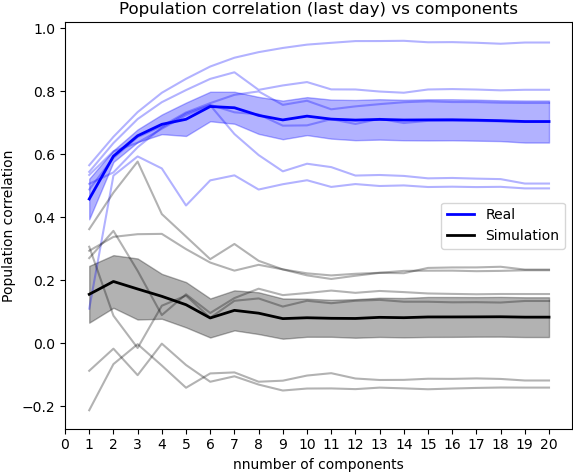

n components,1 comp,2 comp,3 comp,4 comp,5 comp,6 comp,7 comp,8 comp,9 comp,10 comp,11 comp,12 comp,13 comp,14 comp,15 comp,16 comp,17 comp,18 comp,19 comp,20 comp
animal,,,,,,,,,,,,,,,,,,,,
170,0.5439,0.6352,0.7114,0.7650,0.8034,0.8390,0.8599,0.8041,0.8182,0.8289,0.8056,0.8053,0.7988,0.7950,0.8053,0.8066,0.8051,0.8026,0.8044,0.8044
51004,0.1096,0.5319,0.5929,0.5547,0.4371,0.5168,0.5328,0.4878,0.5046,0.5173,0.4960,0.5051,0.4990,0.5008,0.4958,0.4968,0.4955,0.4964,0.4914,0.4914
51007,0.4879,0.5883,0.6543,0.6887,0.7324,0.7620,0.7883,0.7992,0.7564,0.7695,0.7424,0.7517,0.7588,0.7649,0.7677,0.7655,0.7654,0.7634,0.7625,0.7625
63,0.5340,0.6092,0.6363,0.6807,0.7235,0.7552,0.6640,0.5972,0.5455,0.5697,0.5589,0.5321,0.5339,0.5310,0.5233,0.5245,0.5224,0.5208,0.5067,0.5067
64,0.5648,0.6551,0.7336,0.7949,0.8392,0.8782,0.9061,0.9238,0.9371,0.9477,0.9534,0.9589,0.9590,0.9598,0.9552,0.9556,0.9536,0.9505,0.9544,0.9544
65,0.5060,0.5421,0.6219,0.6843,0.7290,0.7567,0.7329,0.7264,0.6905,0.6914,0.7112,0.6959,0.7122,0.6988,0.7059,0.7059,0.7056,0.7037,0.7023,0.7023


n components,1 comp,2 comp,3 comp,4 comp,5 comp,6 comp,7 comp,8 comp,9 comp,10 comp,11 comp,12 comp,13 comp,14 comp,15 comp,16 comp,17 comp,18 comp,19 comp,20 comp
animal,,,,,,,,,,,,,,,,,,,,
170,-0.2128,-0.0664,-0.0030,-0.0709,-0.1414,-0.0959,-0.0927,-0.1223,-0.1189,-0.1027,-0.0951,-0.1120,-0.1167,-0.1164,-0.1128,-0.1132,-0.1117,-0.1134,-0.1183,-0.1183
51004,-0.0875,-0.0174,-0.1014,-0.0014,-0.0692,-0.1224,-0.1050,-0.1313,-0.1502,-0.1439,-0.1435,-0.1458,-0.1409,-0.1433,-0.1462,-0.1439,-0.1419,-0.1406,-0.1409,-0.1409
51007,0.3620,0.4779,0.5765,0.4098,0.3385,0.2667,0.3150,0.2615,0.2342,0.2153,0.2039,0.2141,0.2233,0.2222,0.2390,0.2404,0.2406,0.2427,0.2337,0.2337
63,0.2701,0.3566,0.2297,0.0893,0.1552,0.0958,0.1433,0.1730,0.1526,0.1593,0.1670,0.1599,0.1658,0.1622,0.1579,0.1565,0.1553,0.1562,0.1561,0.1561
64,0.2933,0.3375,0.3460,0.3470,0.2987,0.2560,0.2303,0.2488,0.2343,0.2218,0.2152,0.2203,0.2235,0.2295,0.2302,0.2303,0.2286,0.2296,0.2316,0.2316
65,0.3062,0.0874,-0.0152,0.1190,0.1511,0.0804,0.1346,0.1421,0.1163,0.1347,0.1269,0.1347,0.1376,0.1317,0.1316,0.1298,0.1303,0.1291,0.1340,0.1340


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.131237,19,95,0.006907,2.366286,3.330388e-03,0.135323,0.022304,0.118224
1,condition,20.854719,1,5,20.854719,70.691604,3.901353e-04,0.000390,0.783794,1.000000
2,time * condition,0.480683,19,95,0.025299,7.444695,7.398422e-12,0.013895,0.077115,0.094218


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,1 comp,Real,Simulation,wilcoxon,0.0000,0.0312,0.6250,,0.8987,r,0.4577,0.1552,0.3025,0.2287,6,False,0.0086
1,2 comp,Real,Simulation,t-test,4.5559,0.0061,0.1216,,1.8599,Cohen's d,0.5936,0.1959,0.3977,0.2138,6,True,0.9870
2,3 comp,Real,Simulation,t-test,4.8548,0.0047,0.0931,,1.9820,Cohen's d,0.6584,0.1721,0.4863,0.2454,6,True,0.2869
3,4 comp,Real,Simulation,t-test,7.3046,0.0008,0.0151,*,2.9821,Cohen's d,0.6947,0.1488,0.5459,0.1831,6,True,0.7508
4,5 comp,Real,Simulation,t-test,7.7198,0.0006,0.0116,*,3.1516,Cohen's d,0.7108,0.1221,0.5886,0.1868,6,True,0.0783
5,6 comp,Real,Simulation,t-test,11.3955,9.1087e-05,0.0018,**,4.6522,Cohen's d,0.7513,0.0801,0.6712,0.1443,6,True,0.1982
6,7 comp,Real,Simulation,t-test,9.3243,0.0002,0.0048,**,3.8066,Cohen's d,0.7473,0.1043,0.6431,0.1689,6,True,0.2883
7,8 comp,Real,Simulation,t-test,9.0949,0.0003,0.0054,**,3.7130,Cohen's d,0.7231,0.0953,0.6278,0.1691,6,True,0.5773
8,9 comp,Real,Simulation,t-test,8.3487,0.0004,0.0081,**,3.4083,Cohen's d,0.7087,0.0781,0.6307,0.1850,6,True,0.8997
9,10 comp,Real,Simulation,t-test,8.7668,0.0003,0.0064,**,3.5790,Cohen's d,0.7207,0.0808,0.6400,0.1788,6,True,0.8491


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
plots.plot_average_geometry(
    [pop_corr_real.T, pop_corr_sim.T],
    [str(i) for i in n_components_range],
    colors=['b', 'k'],
    ax=ax,
    title='Population correlation (last day) vs components',
    ylim=None,
    labels=['Real', 'Simulation']
)

plt.xlabel('nnumber of components')
plt.ylabel('Population correlation')
fig.tight_layout()
plt.show()

component_cols = [f'{i} comp' for i in n_components_range]

print_large('\nTWO-WAY REPEATED ANOVA')
anova = st.repeated_measures_anova_general(
    [pop_corr_real.T, pop_corr_sim.T],
    row_labels=st.animal_labels(datapaths), col_labels=component_cols,
    col_name='n components',
    condition_labels=['Real', 'Simulation'],
    title='Last-day (d19) pop correlation vs number of components: real vs simulation')
display(anova[0])
display(anova[1])

